In [1]:
import os,sys, torchaudio, torch
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

if not os.path.exists('barbaros1.wav'):
    os.system('wget http://dihana.cps.unizar.es/~cadrete/barbaros1.wav')

# Waveform

Read and plot the waveform of a wav file.

torch.Size([1, 37001])


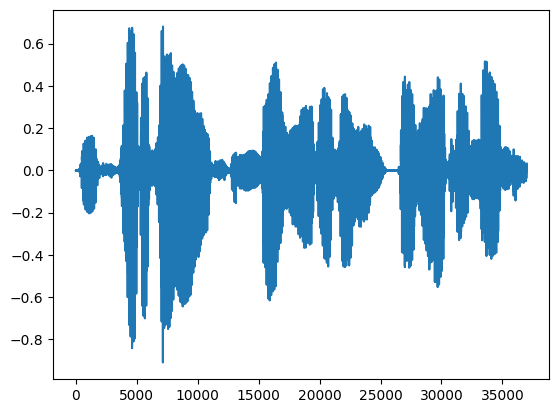

In [2]:
x, fs = torchaudio.load('barbaros1.wav')
print(x.shape)
plt.plot(x[0].numpy())
from IPython.display import Audio
Audio(x[0].numpy(),rate=fs)

# Noise augmentation

Add noise to the waveform with a snr of 5dB.

In [3]:
n, fs2 = torchaudio.load('musan_small/music_small/music-jamendo-0090.wav')
assert fs == fs2

t0 = np.random.randint(0, n.shape[1] - x.shape[1])
n = n[:, t0:t0+x.shape[1]]

p_x = x.std()**2
p_n = n.std()**2
print(p_x, p_n)
print(len(x[0].numpy()), len(n[0].numpy()))
snr = 5


n = n * np.sqrt(p_x/p_n) * np.power(10, -snr/20)

p_x = x.std()**2
p_n = n.std()**2
print(p_x, p_n, 10*np.log10(p_x/p_n))
x_n = x + n
torchaudio.save('out/x_n.wav', x_n, fs)

tensor(0.0126) tensor(0.0465)
37001 37001
tensor(0.0126) tensor(0.0040) tensor(5.)


In [4]:
from IPython.display import Audio
Audio(x_n[0].numpy(),rate=16000)

torch.Size([1, 257, 232])
torch.Size([1, 257, 232])


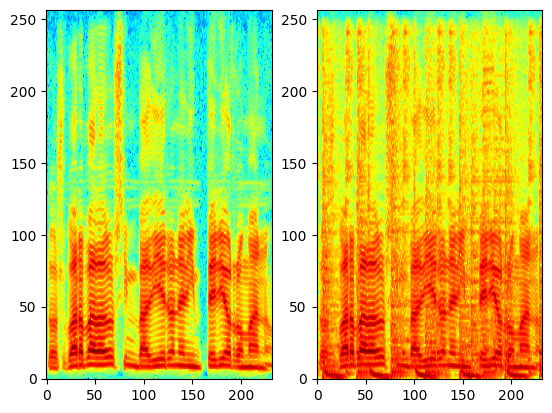

In [5]:
S_x = torchaudio.transforms.Spectrogram(
    n_fft=512, win_length=25*16, hop_length=10*16)(x)       # 25ms window, 10ms shift
print(S_x.shape)

plt.subplot(1,2,1)
plt.imshow(S_x[0].log().numpy(), cmap='jet', aspect='auto',origin='lower') 

S_x_n = torchaudio.transforms.Spectrogram(
    n_fft=512, win_length=25*16, hop_length=10*16)(x_n)       # 25ms window, 10ms shift
print(S_x_n.shape)
plt.subplot(1,2,2)
plt.imshow(S_x_n[0].log().numpy(), cmap='jet', aspect='auto',origin='lower')

# RIR augmentation

Add a room impulse response (RIR) to the waveform.

(16000,) 16000


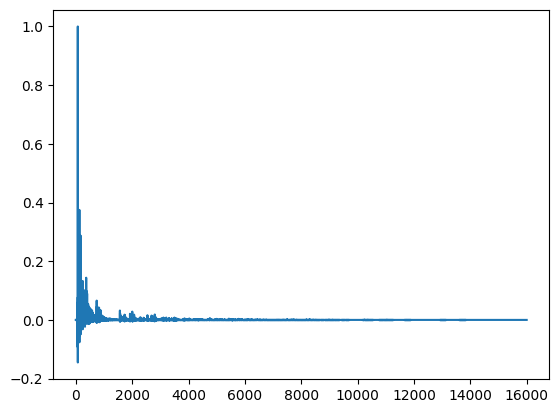

In [6]:
h, fs2 = torchaudio.load('RIRS_NOISES_small/simulated_rirs_small/mediumroom_Room030-00003.wav')
h = h[0].numpy()
h = h / np.max(np.abs(h))

print(h.shape, fs2)
assert fs == fs2

plt.clf()
plt.plot(h)


x_h = sp.signal.convolve(x[0].numpy(), h)
torchaudio.save('out/x_h.wav', torch.tensor(x_h)[None,:], 16000)
Audio(x_h,rate=16000)

torch.Size([1, 257, 232])
torch.Size([257, 332])


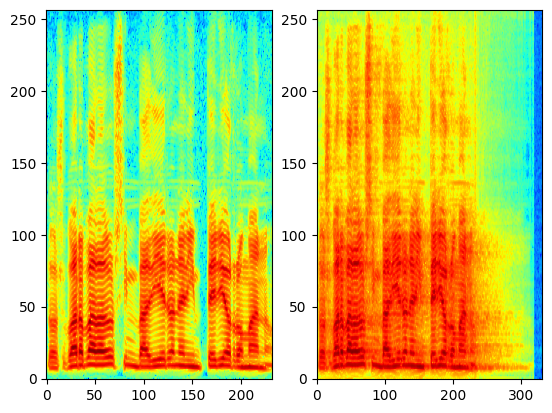

In [7]:
S_x = torchaudio.transforms.Spectrogram(
    n_fft=512, win_length=25*16, hop_length=10*16)(x)       # 25ms window, 10ms shift
print(S_x.shape)

plt.subplot(1,2,1)
plt.imshow(S_x[0].log().numpy(), cmap='jet', aspect='auto',origin='lower') 

S_x_h = torchaudio.transforms.Spectrogram(
    n_fft=512, win_length=25*16, hop_length=10*16)(torch.tensor(x_h))       # 25ms window, 10ms shift
print(S_x_h.shape)
plt.subplot(1,2,2)
plt.imshow(S_x_h.log().numpy(), cmap='jet', aspect='auto',origin='lower')